## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [5]:
import requests
import pandas as pd

# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230


url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

In [ ]:
#hacer la peticion a la api
params = {"latitude": 43.2540, "longitude":-2.9230, "hourly":"temperature_2m", "forecast_days": 7}

response = requests.get(url, params=params)

data = response.json()
data

In [35]:
#procesar Json para pobtener las dos listas:
#extraer listas de time:
hora = data["hourly"]["time"]
print(temperaturas)

#extraer listas de temperaturas:
temperatures = data["hourly"]["temperature_2m"]
print(temperatures)

['2026-03-23T00:00', '2026-03-23T01:00', '2026-03-23T02:00', '2026-03-23T03:00', '2026-03-23T04:00', '2026-03-23T05:00', '2026-03-23T06:00', '2026-03-23T07:00', '2026-03-23T08:00', '2026-03-23T09:00', '2026-03-23T10:00', '2026-03-23T11:00', '2026-03-23T12:00', '2026-03-23T13:00', '2026-03-23T14:00', '2026-03-23T15:00', '2026-03-23T16:00', '2026-03-23T17:00', '2026-03-23T18:00', '2026-03-23T19:00', '2026-03-23T20:00', '2026-03-23T21:00', '2026-03-23T22:00', '2026-03-23T23:00', '2026-03-24T00:00', '2026-03-24T01:00', '2026-03-24T02:00', '2026-03-24T03:00', '2026-03-24T04:00', '2026-03-24T05:00', '2026-03-24T06:00', '2026-03-24T07:00', '2026-03-24T08:00', '2026-03-24T09:00', '2026-03-24T10:00', '2026-03-24T11:00', '2026-03-24T12:00', '2026-03-24T13:00', '2026-03-24T14:00', '2026-03-24T15:00', '2026-03-24T16:00', '2026-03-24T17:00', '2026-03-24T18:00', '2026-03-24T19:00', '2026-03-24T20:00', '2026-03-24T21:00', '2026-03-24T22:00', '2026-03-24T23:00', '2026-03-25T00:00', '2026-03-25T01:00',

In [ ]:
# crear DataFrame columnas hora y temperatura:
df = pd.DataFrame(data) # he probado convariable datapero creoq ue no es así
df

,latitude,longitude,generationtime_ms,utc_offset_seconds,timezone,timezone_abbreviation,elevation,hourly_units,hourly
time,43.25,-2.92,0.126719,0,GMT,GMT,14.0,iso8601,"[2026-03-23T00:00, 2026-03-23T01:00, 2026-03-2..."
temperature_2m,43.25,-2.92,0.126719,0,GMT,GMT,14.0,°C,"[12.3, 12.1, 11.8, 11.5, 11.1, 10.7, 10.8, 11...."


In [ ]:
x= pd.DataFrame({"hora":horas, "temperatura": temperatures})
x


,hora,temperatura
0,2026-03-23T00:00,12.3
1,2026-03-23T01:00,12.1
2,2026-03-23T02:00,11.8
3,2026-03-23T03:00,11.5
4,2026-03-23T04:00,11.1
...,...,...
163,2026-03-29T19:00,8.6
164,2026-03-29T20:00,8.5
165,2026-03-29T21:00,8.4
166,2026-03-29T22:00,8.4


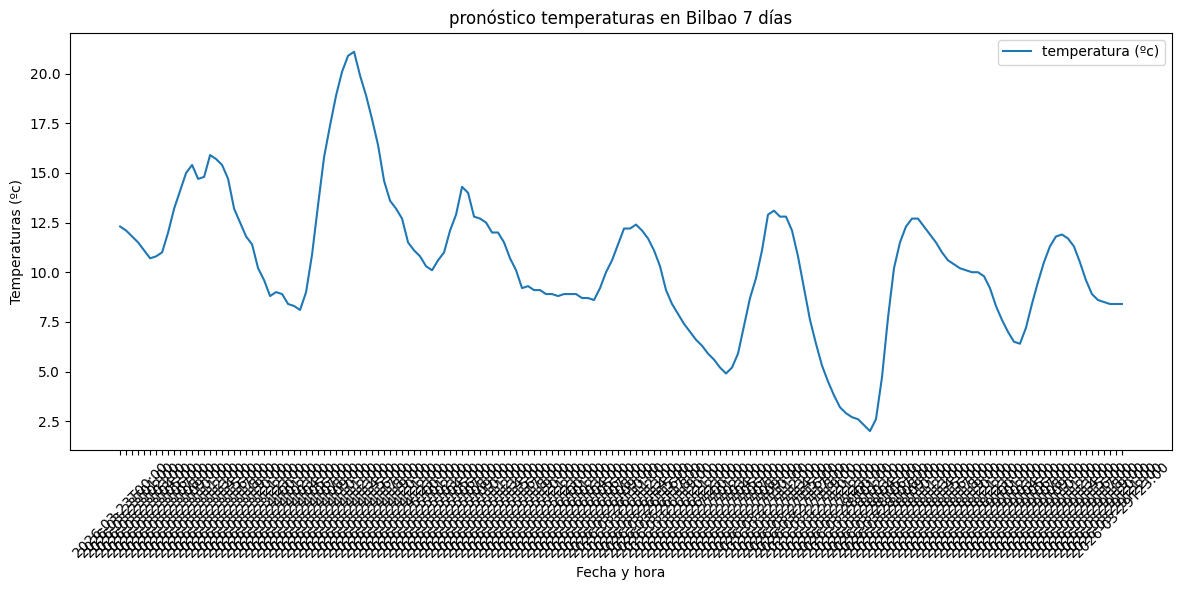

In [ ]:
#visualizacion mediante gráfica:
import matplotlib. pyplot as plt

plt.figure(figsize=(12,6)) ## figsize=(12,6) define el tamaño: 12 de ancho y 6 de alto (en pulgadas)
plt.plot(x["hora"], x["temperatura"], label="temperatura (ºc)") #Eje X: la columna "Hora", y Eje Y la columna "Temperatura".
plt.xlabel("Fecha y hora")
plt.ylabel("Temperaturas (ºc)")
plt.title("pronóstico temperaturas en Bilbao 7 días")
plt.legend() ## Muestra la leyenda
plt.xticks(rotation=45) ## Rota las etiquetas del eje X 45 grados. 
plt.tight_layout() ## Ajusta automáticamente los márgenes para que no se solapen elementos.
plt.show()

# bueno la grafica sale así de feo, he buscado en internet y es porque el eje x tiene muchísimas fechas (una por cada hora) y además están como texto (strings). para solucionarlo tengo que convertir mi variable hora a fecha real. lo hago abajo.

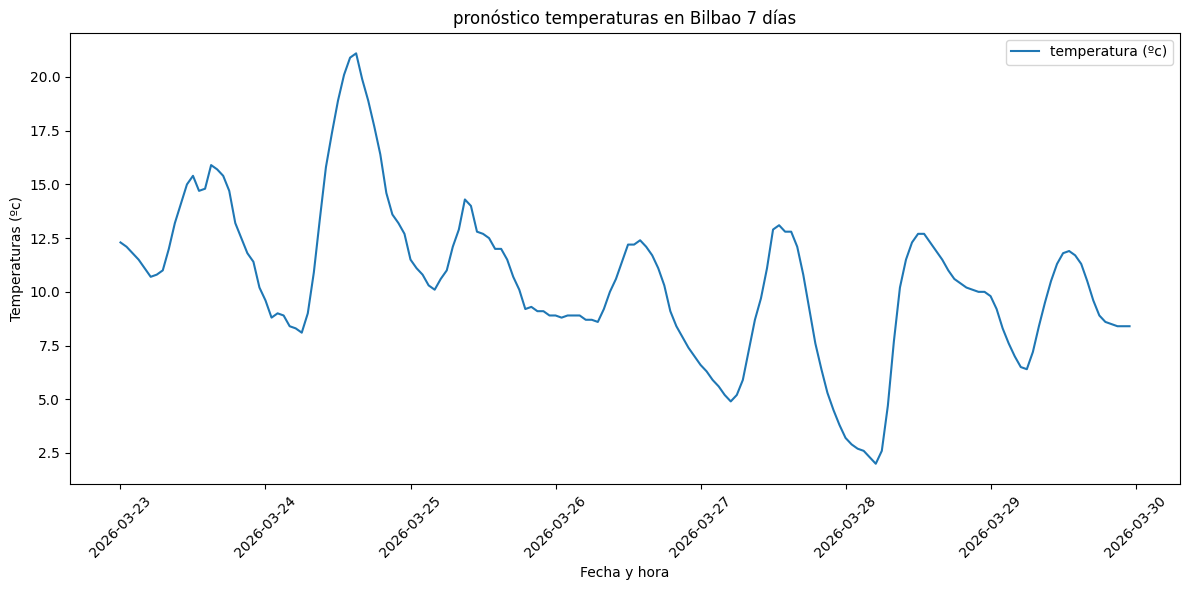

In [ ]:
## Convertir a datetime (ANTES de graficar  porque dentro del plt no me deja poner el "="):

x["hora"] = pd.to_datetime(x["hora"])

plt.figure(figsize=(12,6)) ## figsize=(12,6) define el tamaño: 12 de ancho y 6 de alto (en pulgadas)
plt.plot(x["hora"], x["temperatura"], label="temperatura (ºc)") #Eje X: la columna "Hora", y Eje Y la columna "Temperatura".
plt.xlabel("Fecha y hora")
plt.ylabel("Temperaturas (ºc)")
plt.title("pronóstico temperaturas en Bilbao 7 días")
plt.legend() ## Muestra la leyenda
plt.xticks(rotation=45) ## Rota las etiquetas del eje X 45 grados. 
plt.tight_layout() ## Ajusta automáticamente los márgenes para que no se solapen elementos.
plt.show()

#Arreglaado!!!